In [280]:
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [281]:
def load_sachs_9_stimulations(data_dir: Path = "./data"):
    """
    Загрузка и объединение 9 стимуляций как в статье Khondker et al.
    """
    all_data = []
    simulation_ids = []

    # Файлы в порядке, указанном в статье
    files = [
        '1. cd3cd28.xls',           # simulation 1
        '2. cd3cd28icam2.xls',      # simulation 2
        '3. cd3cd28+aktinhib.xls',  # simulation 3
        '4. cd3cd28+g0076.xls',     # simulation 4
        '5. cd3cd28+psitect.xls',   # simulation 5
        '6. cd3cd28+u0126.xls',     # simulation 6
        '7. cd3cd28+ly.xls',        # simulation 7
        '8. pma.xls',               # simulation 8
        '9. b2camp.xls'             # simulation 9
    ]

    proteins = ['praf', 'pmeK', 'plcg', 'PIP2', 'PIP3', 'p44/42',
                'pakts473', 'PKA', 'PKC', 'P38', 'pjnk']

    for sim_id, fname in enumerate(files, 1):
        filepath = Path(data_dir) / fname
        if filepath.exists():
            # Загрузка Excel файла
            df = pd.read_excel(filepath)
            df.columns = proteins

            # Предполагается, что данные: 11 колонок (белки) x N строк (клетки)
            df.columns = proteins
            all_data.append(df)
            simulation_ids.extend([sim_id] * len(df))
            print(f"Loaded {fname}: {len(df)} cells")
        else:
            print(f"File not found: {filepath}")

    if all_data:
        combined = pd.concat(all_data, ignore_index=True)
        return combined, np.array(simulation_ids)
    else:
        return None, None

data, simulation_ids = load_sachs_9_stimulations()

Loaded 1. cd3cd28.xls: 853 cells
Loaded 2. cd3cd28icam2.xls: 902 cells
Loaded 3. cd3cd28+aktinhib.xls: 911 cells
Loaded 4. cd3cd28+g0076.xls: 723 cells
Loaded 5. cd3cd28+psitect.xls: 810 cells
Loaded 6. cd3cd28+u0126.xls: 799 cells
Loaded 7. cd3cd28+ly.xls: 848 cells
Loaded 8. pma.xls: 913 cells
Loaded 9. b2camp.xls: 707 cells


In [282]:
def preprocess_sachs_data(data: pd.DataFrame, simulation_ids: np.ndarray) -> np.ndarray:
    """
    Предобработка данных
    """
    d = data.shape[1]  # 11 белков
    n_simulations = len(np.unique(simulation_ids))  # 9

    # 1. Логарифмическое преобразование (как в оригинальной статье Sachs)
    #    Данные flow cytometry обычно логарифмируют
    data_log = np.log1p(data.values)  # log(1 + x) для избежания log(0)

    # 2. Стандартизация каждого белка (fixed effect of protein)
    scaler = StandardScaler()
    data_std = scaler.fit_transform(data_log)

    # 3. Коррекция на эффект симуляции (random simulation effect)
    data_adjusted = data_std.copy()
    simulation_effects = []

    for sim_id in range(1, n_simulations + 1):
        mask = simulation_ids == sim_id
        if mask.any():
            # Вычитаем среднее по каждой стимуляции
            sim_mean = data_std[mask].mean(axis=0)
            data_adjusted[mask] -= sim_mean
            simulation_effects.append(sim_mean)

    # 4. Финальная стандартизация
    final_scaler = StandardScaler()
    data_final = final_scaler.fit_transform(data_adjusted)

    print(f"Shape after preprocessing: {data_final.shape}")
    print(f"Mean: {data_final.mean():.6f}, Std: {data_final.std():.6f}")

    return data_final, simulation_effects

# Применяем
data_preprocessed, sim_effects = preprocess_sachs_data(data, simulation_ids)

Shape after preprocessing: (7466, 11)
Mean: -0.000000, Std: 1.000000


In [283]:
data_preprocessed

array([[-0.79620982, -0.88073866, -0.80448679, ...,  0.49708635,
         0.45844072,  0.58374223],
       [-0.40334601, -0.5758853 , -0.35259332, ..., -1.33712978,
        -0.63996456,  1.07752111],
       [ 0.24702326,  0.80524266, -0.11497406, ...,  0.01420786,
         0.0791249 , -0.22808392],
       ...,
       [-0.21749337,  0.91900944, -0.0871972 , ..., -0.39736543,
        -1.74685037,  0.01898557],
       [ 0.04858875,  1.48643385, -1.69475517, ...,  3.65115984,
         5.33889467,  0.17927745],
       [-0.11289982, -0.54689924, -1.38239187, ..., -0.39736543,
        -2.10960494, -0.12630707]])

In [284]:
class BCLASSO:
    """BCLASSO специально для данных Sachs (11 белков)"""

    def __init__(self, rng: np.random.Generator = None):
        self.rng = rng if rng else np.random.default_rng(42)

    def fit(self, Y: np.ndarray, rho: float = 1.0,
            n_iter: int = 80000, n_burn: int = 20000,
            nthin: int = 10):
        """
        Запуск BCLASSO как в статье
        """
        n, d = Y.shape
        S = np.cov(Y.T)

        # Инициализация
        Phi = np.linalg.inv(S + 0.1 * np.eye(d))

        # Хранение samples (после прореживания)
        n_save = (n_iter - n_burn) // nthin
        phi_samples = np.zeros((n_save, d, d))

        for iter_idx in range(n_iter):
            # Обновляем каждую колонку
            for k in range(d):
                Phi = self._update_column(Phi, S, k, n, rho)

            # Сохраняем после burn-in
            if iter_idx >= n_burn and (iter_idx - n_burn) % nthin == 0:
                save_idx = (iter_idx - n_burn) // nthin
                phi_samples[save_idx] = Phi.copy()

        # Posterior mean
        Phi_mean = phi_samples.mean(axis=0)

        # Credible intervals (для thresholding)
        lower = np.percentile(phi_samples, 37.5, axis=0)   # 37.5% percentile
        upper = np.percentile(phi_samples, 62.5, axis=0)   # 62.5% percentile

        # BCLASSOs: обнуляем элементы, чей CI содержит 0
        Phi_sparse = Phi_mean.copy()
        zero_mask = (lower * upper <= 0)
        Phi_sparse[zero_mask] = 0

        return {
            'Phi_mean': Phi_mean,
            'Phi_sparse': Phi_sparse,
            'samples': phi_samples,
            'credible_intervals': (lower, upper)
        }
    def _update_column(self, Phi, S, k, n, rho):
        d = Phi.shape[0]
        idx = np.arange(d) != k

        Phi_kk = Phi[idx][:, idx]
        phi_k = Phi[idx, k]
        phi_kk = Phi[k, k]

        inv_Phi_kk = np.linalg.inv(Phi_kk)

        # --- Gamma update ---
        shape = n / 2 + 1
        rate = (n / 2) * S[k, k] + rho
        gamma_sample = self.rng.gamma(shape, 1 / rate)

        quad_form = phi_k @ inv_Phi_kk @ phi_k
        phi_kk_new = quad_form + gamma_sample

        # --- Metropolis step ---
        proposal_scale = 0.01
        phi_k_proposal = phi_k + self.rng.normal(0, proposal_scale, size=d-1)

        quad_proposal = phi_k_proposal @ inv_Phi_kk @ phi_k_proposal

        if phi_kk_new > quad_proposal:
            log_current = (
                0.5 * n * np.log(phi_kk - quad_form)
                - n * (S[idx, k] @ phi_k)
                - rho * np.sum(np.abs(phi_k))
            )

            log_proposal = (
                0.5 * n * np.log(phi_kk_new - quad_proposal)
                - n * (S[idx, k] @ phi_k_proposal)
                - rho * np.sum(np.abs(phi_k_proposal))
            )

            if np.log(self.rng.random()) < log_proposal - log_current:
                phi_k = phi_k_proposal

        # --- update matrix ---
        Phi_new = Phi.copy()
        Phi_new[k, k] = phi_kk_new
        Phi_new[idx, k] = phi_k
        Phi_new[k, idx] = phi_k

        return Phi_new

In [285]:
# Запуск как в статье
print("Запуск BCLASSO...")
bclasso = BCLASSO(rng=np.random.default_rng(42))

results = bclasso.fit(
    Y=data_preprocessed,
    rho=1.0,
    n_iter=80000,
    n_burn=20000,
    nthin=10
)

print(f"Posterior mean shape: {results['Phi_mean'].shape}")
print(f"Sparsity level: {(results['Phi_sparse'] == 0).sum() / 121:.2%}")

Запуск BCLASSO...
Posterior mean shape: (11, 11)
Sparsity level: 61.16%


Number of connections: 18


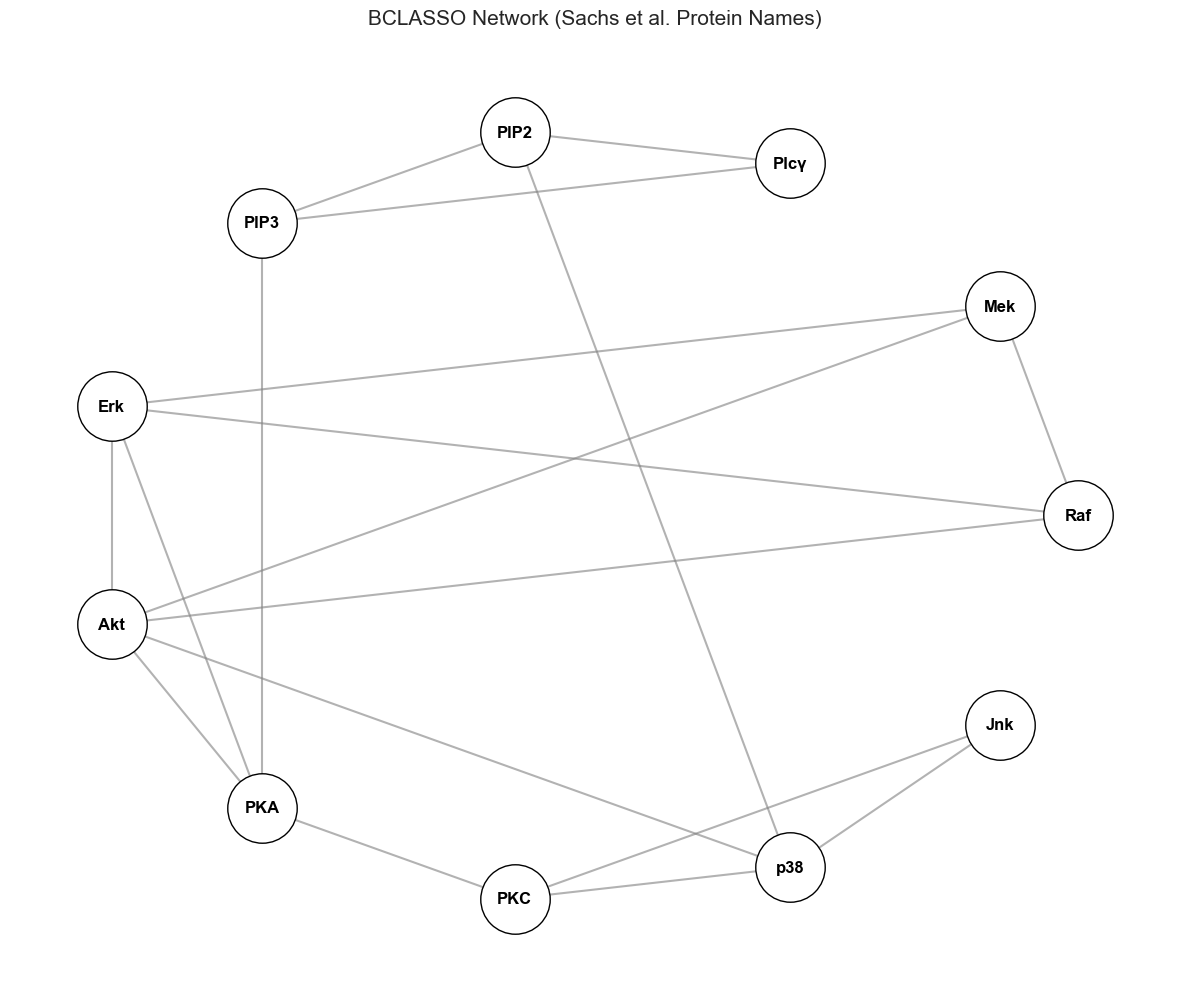

Number of connections: 18


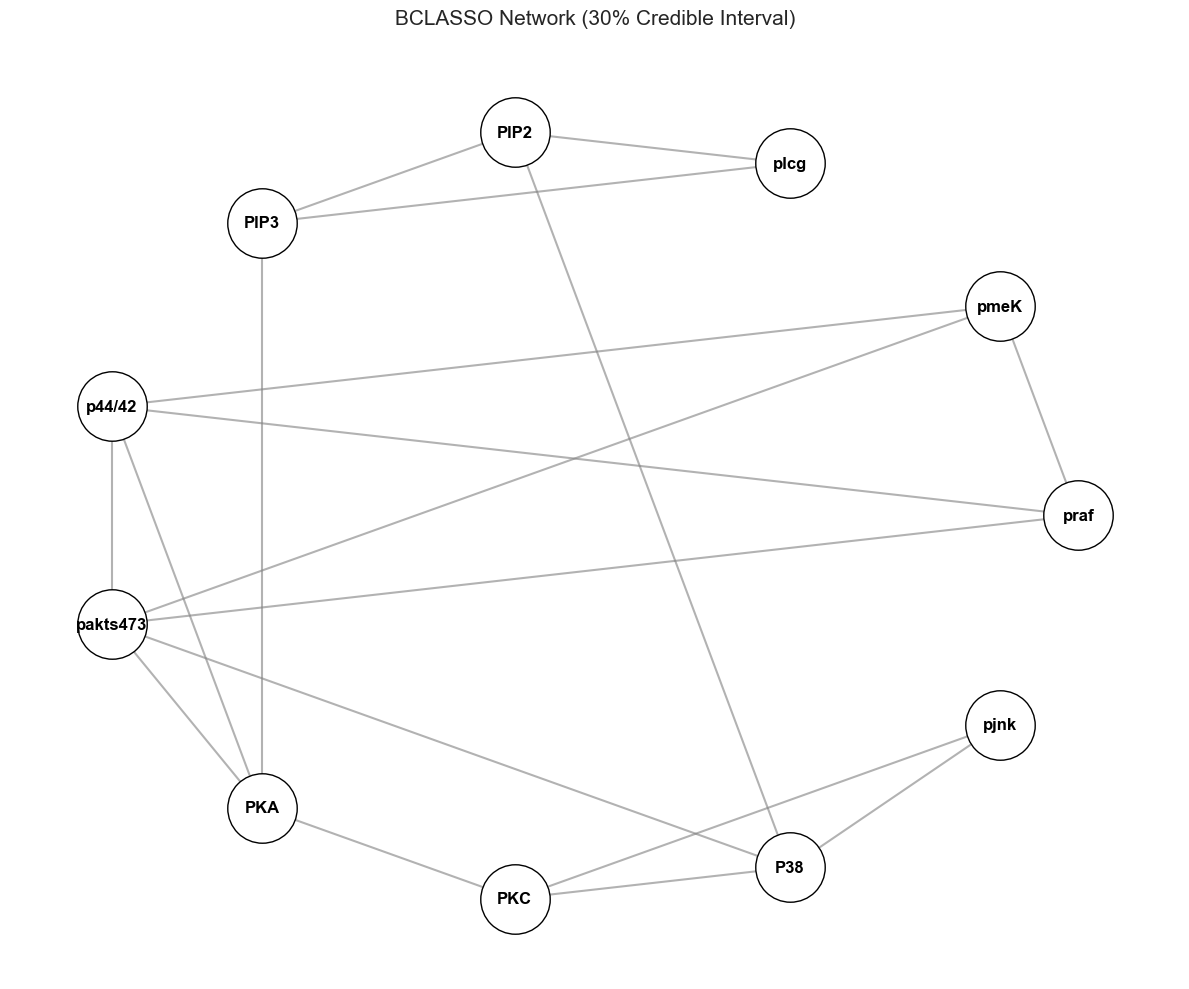

In [286]:
def plot_protein_network(Phi_sparse, protein_names, title="Bayesian Network"):
    """Построение графа взаимодействий белков"""

    # Создаём граф
    G = nx.Graph()
    d = Phi_sparse.shape[0]

    # Добавляем узлы
    G.add_nodes_from(protein_names)

    # Добавляем рёбра для ненулевых partial correlations
    for i in range(d):
        for j in range(i+1, d):
            if abs(Phi_sparse[i, j]) > 1e-6:  # ненулевая связь
                G.add_edge(protein_names[i], protein_names[j])

    print(f"Number of connections: {G.number_of_edges()}")

    # Визуализация
    plt.figure(figsize=(12, 10))
    pos = nx.circular_layout(G)

    nx.draw_networkx_nodes(G, pos, node_color='white',
                           edgecolors='black', node_size=2500)

    # Отрисовка подписей
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    # Отрисовка ребер (сделаем их чуть тоньше и серыми)
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6, width=1.5)

    plt.title(title, pad=20, fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return G

# Белки в правильном порядке (как в данных)
protein_names = ['praf', 'pmeK', 'plcg', 'PIP2', 'PIP3', 'p44/42',
                 'pakts473', 'PKA', 'PKC', 'P38', 'pjnk']

# Белки в правильном порядке, но с названиями как в статье
protein_names_article = [
    'Raf', 'Mek', 'Plcγ', 'PIP2', 'PIP3', 'Erk',
    'Akt', 'PKA', 'PKC', 'p38', 'Jnk'
]

# Вызов функции с новыми именами
G = plot_protein_network(
    results['Phi_sparse'],
    protein_names_article,
    title="BCLASSO Network (Sachs et al. Protein Names)"
)

# Строим сеть
G = plot_protein_network(results['Phi_sparse'], protein_names,
                         title="BCLASSO Network (30% Credible Interval)")

In [287]:
true_edges = {
    ('praf', 'pmeK'),
    ('pmeK', 'p44/42'),
    ('plcg', 'PIP2'),
    ('plcg', 'PIP3'),
    ('PIP2', 'PKC'),
    ('PIP3', 'pakts473'),
    ('PKC', 'praf'),
    ('PKC', 'P38'),
    ('PKC', 'pjnk'),
    ('PKA', 'praf'),
    ('PKA', 'pmeK'),
    ('PKA', 'p44/42'),
    ('PKA', 'akt'),        # pakts473
}

In [288]:
true_edges_undirected = {tuple(sorted(e)) for e in true_edges}

In [289]:
def get_predicted_edges(Phi_sparse, protein_names, threshold=1e-6):
    edges = set()
    d = len(protein_names)

    for i in range(d):
        for j in range(i+1, d):
            if abs(Phi_sparse[i, j]) > threshold:
                a, b = protein_names[i], protein_names[j]
                edges.add(tuple(sorted((a, b))))

    return edges

In [290]:
def evaluate_network(pred_edges, true_edges):
    tp = len(pred_edges & true_edges)
    fp = len(pred_edges - true_edges)
    fn = len(true_edges - pred_edges)

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

    return {
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [291]:
pred_edges = get_predicted_edges(results['Phi_sparse'], protein_names)

metrics = evaluate_network(pred_edges, true_edges_undirected)

print("=== Evaluation ===")
for k, v in metrics.items():
    print(f"{k}: {v}")

=== Evaluation ===
TP: 7
FP: 11
FN: 6
precision: 0.3888888888888889
recall: 0.5384615384615384
f1: 0.45161290322580644
